In [1]:
#@title import dataset
import pandas as pd

# Carico il file CSV con i dati delle transazioni in un DataFrame
df = pd.read_csv('AI_machine_learning_data_set.csv')
df.head()  # Do un'occhiata alle prime righe per controllare che tutto sia a posto

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:

#@title visualizzazione dati

print("\n--INFORMAZIONI DATASET:--")  # Tipi di colonne, numero di righe, memoria occupata
df.info()

print("\n--VALORI MANCANTI:--")  # Verifico se ci sono celle vuote o nulle
print(df.isnull().sum())

print("\n--DIMENSIONE DATASET:--")  # Quante righe e colonne ha il dataset
print(df.shape)

print("\n--CONTEGGIO FRODI:--")  # Quante transazioni sono frodi (1) e quante lecite (0)
print(df['isFraud'].value_counts())

# Calcolo la percentuale di transazioni fraudolente sul totale
fraud_count=df['isFraud'].value_counts()[1]
total_rows=df.shape[0]
fraud_percentage=fraud_count / total_rows * 100
print(f"\n--PERCENTUALE FRODI: {fraud_percentage: .2f}%--")


--INFORMAZIONI DATASET:--
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB

--VALORI MANCANTI:--
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

--DIMENSIONE DATASET:--
(6362620, 11)

--CONTEGGIO FRODI:--
isFraud
0    6354407
1       8213
Name: count, dtype: int64

--PERCENTUALE FRODI:  0.13%--


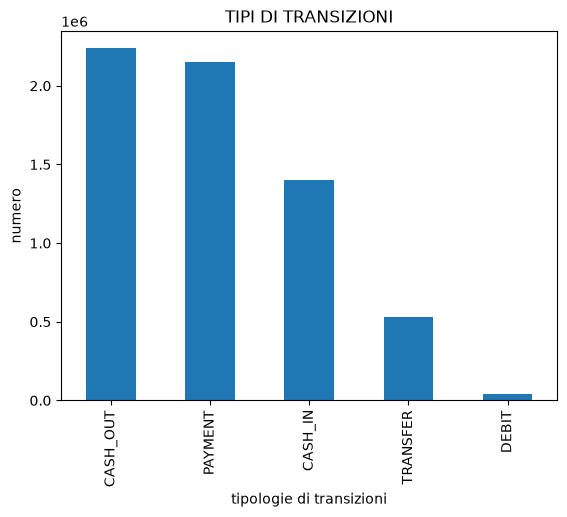

In [3]:
#@title visualizzazione grafica dati

import matplotlib.pyplot as plt

# Grafico a barre con il numero di transazioni per ogni tipologia (payment, transfer, ecc.)
df['type'].value_counts().plot(kind='bar')
plt.title('TIPI DI TRANSIZIONI')
plt.xlabel('tipologie di transizioni')
plt.ylabel('numero')
plt.show()

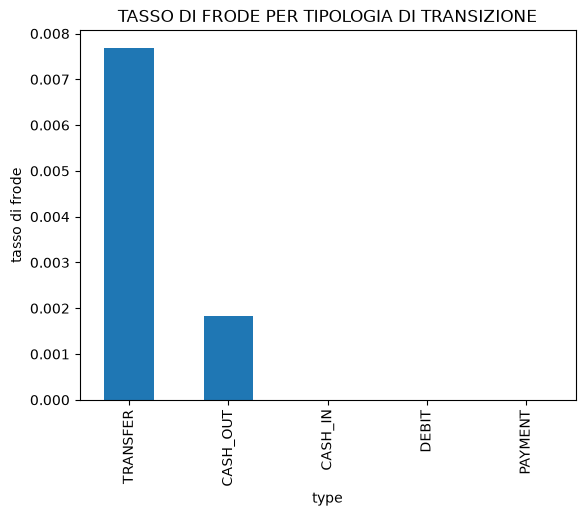

In [4]:
# @title
# Grafico che mostra, per ogni tipo di transazione, la quota di frodi sul totale
fraud_by_type=df\
               .groupby('type')['isFraud']\
               .mean()\
               .sort_values(ascending=False)

fraud_by_type.plot(kind='bar',title='TASSO DI FRODE PER TIPOLOGIA DI TRANSIZIONE')
plt.ylabel("tasso di frode")
plt.show()


c:\Users\Vladimir\fraud_detection_project_update\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


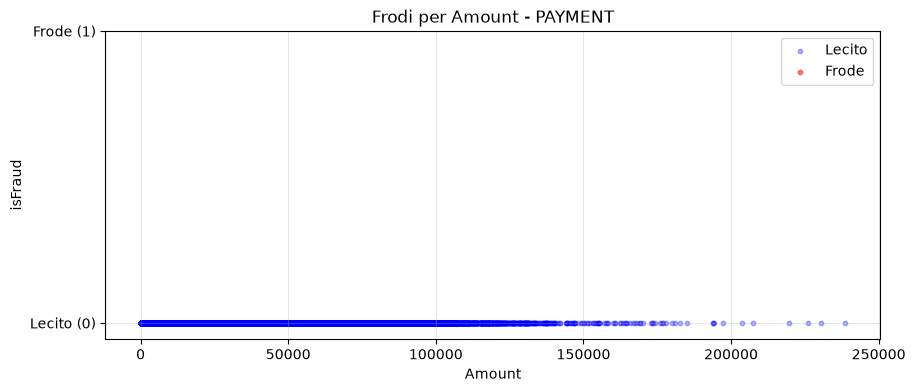

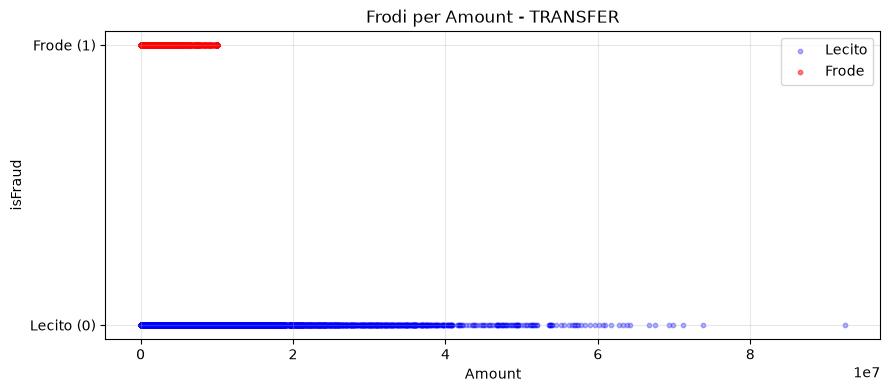

c:\Users\Vladimir\fraud_detection_project_update\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


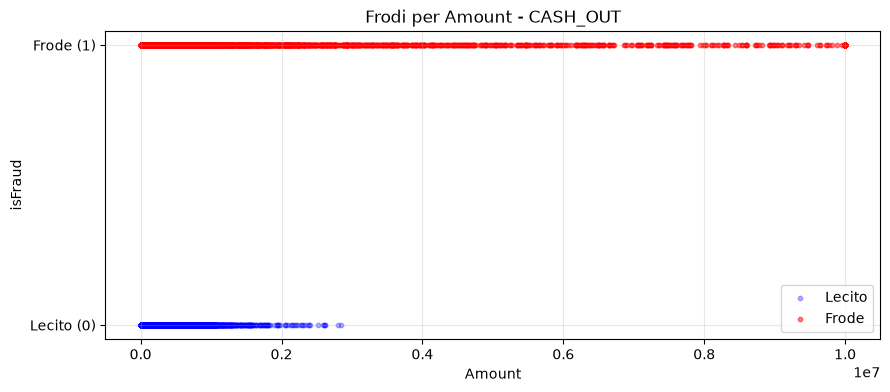

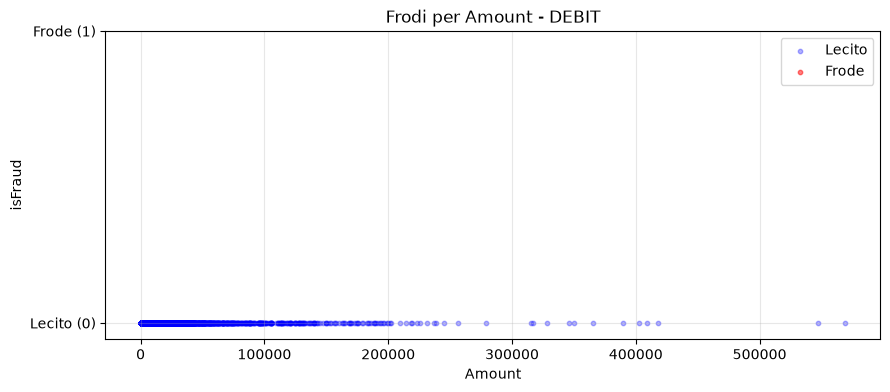

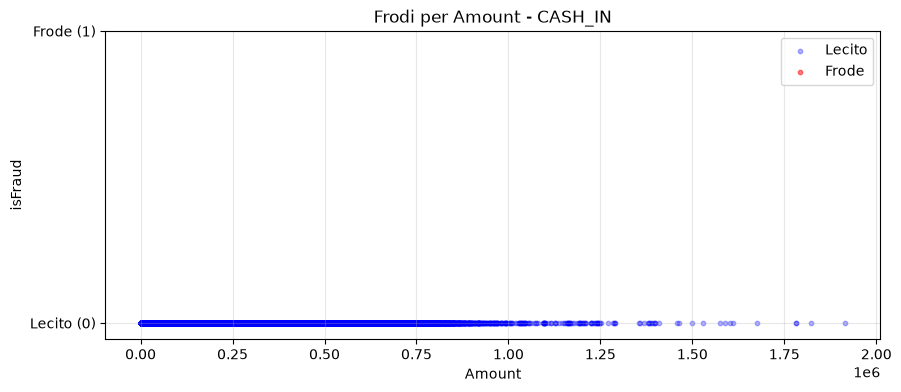

In [5]:
transaction_types = df['type'].unique()

# Per ogni tipo di transazione, scatter plot di importo vs esito (frode o lecita),
# per vedere a colpo d'occhio se le frodi si concentrano su certi importi
for t in transaction_types:
    subset = df[df['type'] == t]

    plt.figure(figsize=(10, 4))
    plt.scatter(subset[subset['isFraud'] == 0]['amount'], subset[subset['isFraud'] == 0]['isFraud'], alpha=0.3, s=10, color='blue', label='Lecito')
    plt.scatter(subset[subset['isFraud'] == 1]['amount'], subset[subset['isFraud'] == 1]['isFraud'], alpha=0.5, s=10, color='red', label='Frode')

    plt.title(f'Frodi per Amount - {t}')
    plt.xlabel('Amount')
    plt.ylabel('isFraud')
    plt.yticks([0, 1], ['Lecito (0)', 'Frode (1)'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Text(0.5, 1.0, 'Matrice di Correlazione')

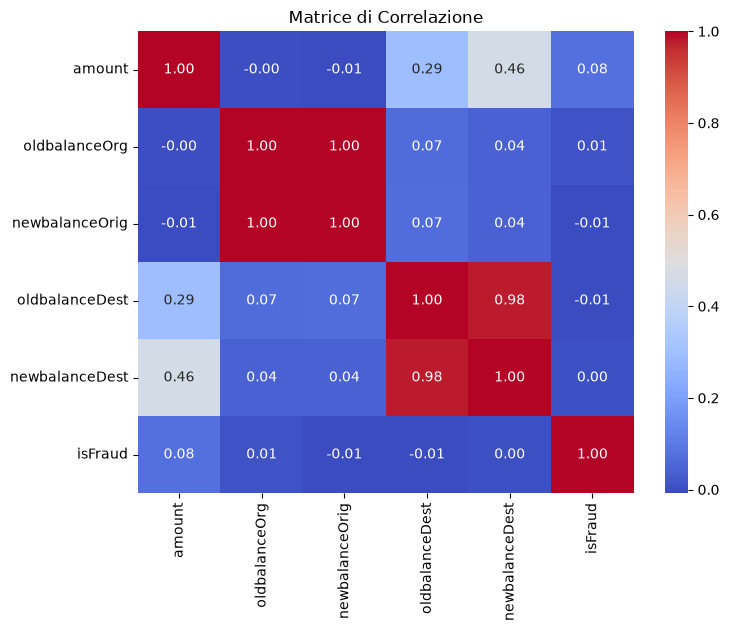

In [6]:
# Matrice di correlazione tra le colonne numeriche e la variabile target isFraud,
# per capire quali variabili sono più legate alle frodi

import seaborn as sns

numeric_cols = ['amount' , 'oldbalanceOrg' , 'newbalanceOrig' , 'oldbalanceDest' , 'newbalanceDest' , 'isFraud']
correlation_matrix = df[numeric_cols].corr()

# Creo e mostro la heatmap della matrice di correlazione
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix , annot=True , cmap='coolwarm' , fmt=".2f")
plt.title('Matrice di Correlazione')


In [7]:
# Creo un nuovo DataFrame pulito da usare per il modello: tolgo lo step (tempo),
# i nomi di mittente e destinatario e isFlaggedFraud, perché non aiutano a prevedere la frode
df_model = df.drop(['step' , 'nameOrig' , 'nameDest' , 'isFlaggedFraud'], axis=1)

# Nuove Feature: differenze contabili, molto indicative di frode nel dataset PaySim
# (le frodi lasciano spesso un'incongruenza tra il saldo che ci si aspetterebbe dopo
# la transazione e quello effettivamente registrato)
df_model['errorBalanceOrig'] = df_model['oldbalanceOrg'] - df_model['amount'] - df_model['newbalanceOrig']
df_model['errorBalanceDest'] = df_model['oldbalanceDest'] + df_model['amount'] - df_model['newbalanceDest']

print("\nNUOVO DATASET")
print("Dimensioni:", df_model.shape)
df_model.head()



NUOVO DATASET
Dimensioni: (6362620, 9)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14


In [8]:
# Divido il dataset in training (60%), validation (20%) e test (20%),
# mantenendo la stessa proporzione di frodi in ogni set (stratify)
from sklearn.model_selection import train_test_split

# Separo la variabile target (isFraud) dal resto delle colonne
y=df_model['isFraud']
x=df_model.drop('isFraud', axis=1)

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# class_weight='balanced' nel modello (vedi pipeline) per gestire lo sbilanciamentotenendo tutti i dati di training
print(f"Training set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set: {x_test.shape}")
print("\nConteggio frodi nel training set:")
print(y_train.value_counts())

Training set: (3817572, 8)
Validation set: (1272524, 8)
Test set: (1272524, 8)

Conteggio frodi nel training set:
isFraud
0    3812644
1       4928
Name: count, dtype: int64


In [9]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [10]:
# Pre-elaborazione dei dati prima di addestrare il modello
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Distinguo le colonne numeriche da quella categorica (testuale)
categorical =['type']
numeric =['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']

# Preprocessor: standardizzo le colonne numeriche e trasformo quella categorica in variabili dummy
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numeric),
        ('cat', OneHotEncoder(drop='first'),categorical)
        ],
    remainder='drop'
)

# Pipeline completa: prima il preprocessing, poi il modello di regressione logistica
# class_weight='balanced' pesa di più la classe frode durante l'addestramento

pipeline= Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression( max_iter=1000, class_weight='balanced'))
])

print("Pipeline creata con successo")

Pipeline creata con successo


In [11]:
# Addestro la pipeline sui dati di training

print("addestramento pipeline in corso")
pipeline.fit(x_train, y_train)
print ("addestramento completato")


addestramento pipeline in corso
addestramento completato


In [12]:
# Visualizzo la pipeline addestrata (nessun bisogno di rifittarla: è già stata addestrata sopra)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['type','amount','oldbalanceOrg',...,'newbalanceDest','errorBalanceOrig', 'errorBalanceDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [13]:
# Trovo la soglia ottimale (quella che massimizza l'F1) usando il validation set
y_val_proba = pipeline.predict_proba(x_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f"Soglia ottimale trovata su validation (F1 massimo): {best_threshold:.3f}")

# Applico la soglia ottimizzata sulle probabilità del test set
y_test_proba = pipeline.predict_proba(x_test)[:, 1]
y_pred = (y_test_proba >= best_threshold).astype(int)

# Stampo il report con precision, recall e f1-score
print("\nREPORT:")
print(classification_report(y_test, y_pred))

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# La trasformo in un DataFrame con etichette leggibili per righe e colonne
cm_con_titoli = pd.DataFrame(cm, 
                             columns=['PREDETTO LECITO', 'PREDETTO FRODE'], 
                             index=['REALE LECITO', 'REALE FRODE'])

# Stampo a schermo la matrice formattata
print("\nMATRICE DI CONFUSIONE:")
print(cm_con_titoli)

# Calcolo l'accuratezza globale del modello (con la soglia ottimizzata)
accuracy = (y_pred == y_test.values).mean()
print(f"\nACCURATEZZA GLOBALE: { accuracy: .2%}")

Soglia ottimale trovata su validation (F1 massimo): 1.000

REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270882
           1       0.72      0.49      0.58      1642

    accuracy                           1.00   1272524
   macro avg       0.86      0.74      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524


MATRICE DI CONFUSIONE:
              PREDETTO LECITO  PREDETTO FRODE
REALE LECITO          1270579             303
REALE FRODE               844             798

ACCURATEZZA GLOBALE:  99.91%


In [14]:
# Esporto la pipeline addestrata su file, così la posso riusare senza doverla riallenare da capo
import joblib

joblib.dump(pipeline,'fraud_detection_pipeline.pickle')
print("Modello salvato con successo")


Modello salvato con successo
